見つかったファイル: Lx_24_Nd_500_NT_34560_px_0.0_MPI_hexagonal6.npz


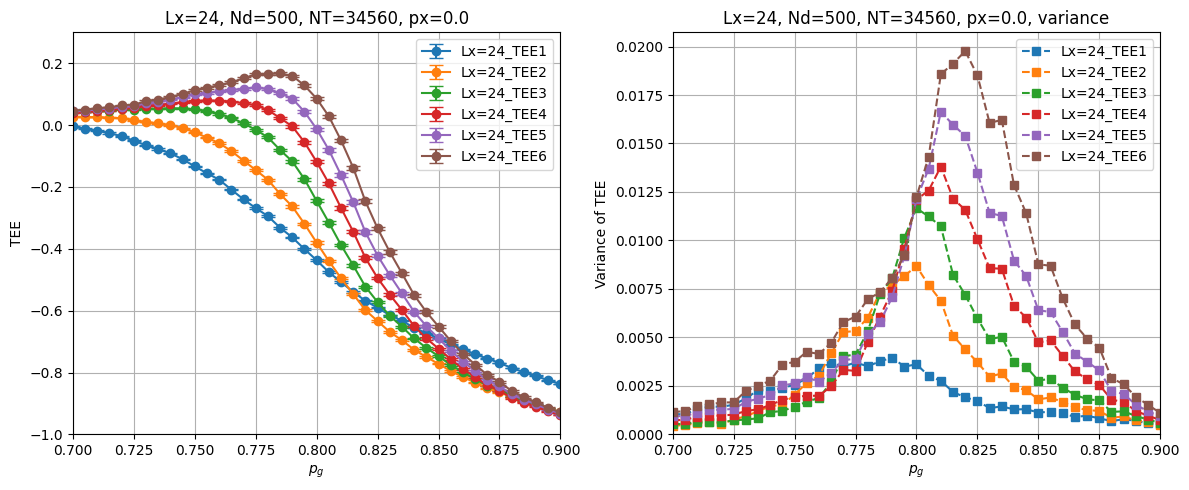

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os

cmap = plt.colormaps['gnuplot']

# ファイル名を指定
filename = "Lx_24_Nd_500_NT_34560_px_0.0_MPI_hexagonal6.npz"
print("見つかったファイル:", filename)

# 情報抽出
match = re.search(r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)_px_([0-9.]+)_", filename)
if match:
    Lx = int(match.group(1))
    Nd = int(match.group(2))
    NT = int(match.group(3))
    px = float(match.group(4))
    title_suffix = f"Lx={Lx}, Nd={Nd}, NT={NT}, px={px}"
else:
    title_suffix = os.path.basename(filename)

# 読み込みとプロット
with np.load(filename) as data:
    pg = data['pg']
    TEE1_ave = data['TEE1_ave']
    TEE1_err = data['TEE1_err']
    TEE1_var = data['TEE1_var']
    TEE2_ave = data['TEE2_ave']
    TEE2_err = data['TEE2_err']
    TEE2_var = data['TEE2_var']
    TEE3_ave = data['TEE3_ave']
    TEE3_err = data['TEE3_err']
    TEE3_var = data['TEE3_var']
    TEE4_ave = data['TEE4_ave']
    TEE4_err = data['TEE4_err']
    TEE4_var = data['TEE4_var']
    TEE5_ave = data['TEE5_ave']
    TEE5_err = data['TEE5_err']
    TEE5_var = data['TEE5_var']
    TEE6_ave = data['TEE6_ave']
    TEE6_err = data['TEE6_err']
    TEE6_var = data['TEE6_var']

label1 = f"Lx={Lx}_TEE1"
label2 = f"Lx={Lx}_TEE2"
label3 = f"Lx={Lx}_TEE3"
label4 = f"Lx={Lx}_TEE4"
label5 = f"Lx={Lx}_TEE5"
label6 = f"Lx={Lx}_TEE6"

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 平均と誤差
ax[0].errorbar(pg, TEE1_ave, yerr=TEE1_err, fmt='o-', capsize=5, label=label1)
ax[0].errorbar(pg, TEE2_ave, yerr=TEE2_err, fmt='o-', capsize=5, label=label2)
ax[0].errorbar(pg, TEE3_ave, yerr=TEE3_err, fmt='o-', capsize=5, label=label3)
ax[0].errorbar(pg, TEE4_ave, yerr=TEE4_err, fmt='o-', capsize=5, label=label4)
ax[0].errorbar(pg, TEE5_ave, yerr=TEE5_err, fmt='o-', capsize=5, label=label5)
ax[0].errorbar(pg, TEE6_ave, yerr=TEE6_err, fmt='o-', capsize=5, label=label6)

# 分散
ax[1].plot(pg, TEE1_var, 's--', label=label1)
ax[1].plot(pg, TEE2_var, 's--', label=label2)
ax[1].plot(pg, TEE3_var, 's--', label=label3)
ax[1].plot(pg, TEE4_var, 's--', label=label4)
ax[1].plot(pg, TEE5_var, 's--', label=label5)
ax[1].plot(pg, TEE6_var, 's--', label=label6)

# 描画設定
ax[0].set_xlabel('$p_g$')
ax[0].set_ylabel('TEE')
ax[0].set_xlim(0.7, 0.9)
ax[0].set_ylim(-1, 0.3)
ax[0].set_title(title_suffix)
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('$p_g$')
ax[1].set_ylabel('Variance of TEE')
ax[1].set_xlim(0.7, 0.9)
ax[1].set_ylim(0)
ax[1].set_title(title_suffix + ", variance")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.savefig(f"px_{px}_Lx_{Lx}_Nd_{Nd}_NT_{NT}_MPI_results.png", dpi=300, bbox_inches='tight')
plt.show()
